In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import pi

In [2]:
df = pd.read_csv('NER_benchmark_results.csv')

In [31]:
print(len(df))
df.head(10)

1401668


,docid,text,text_lang,model,duration,entity_count,tfidf_score,seq_avg_len,seq_uniq_ratio,seq_context_sim,avg_entity_length,entity_stability,entities
0,3#0,"Paul Jules Antoine Meillet, né le à Moulins (A...",fr,spacy-xx_ent_wiki_sm,1.684165,5,0.000000,1.000000,0.80,0.000000,1.000000,1.0,"['Paul Jules Antoine Meillet', 'Moulins', 'All..."
1,3#0,"Paul Jules Antoine Meillet, né le à Moulins (A...",fr,wikineural-multilingual-ner,0.154518,5,2.828427,1.600000,1.00,0.000000,11.600000,1.0,"[('Paul Jules Antoine Meillet', 'PER'), ('Moul..."
2,3#0,"Paul Jules Antoine Meillet, né le à Moulins (A...",fr,bert-base-multilingual-cased,0.013205,12,4.157609,2.416667,1.00,0.268641,12.333333,1.0,"[('Paul', 'LABEL_0'), ('Jules Antoine Meillet,..."
3,3#0,"Paul Jules Antoine Meillet, né le à Moulins (A...",fr,bert-base-historic-multilingual-cased,0.009076,3,4.157609,9.666667,1.00,0.489823,51.666667,1.0,"[('Paul Jules Antoine Meillet, né le à Moulins..."
4,3#0,Il est aussi philologue.,fr,spacy-xx_ent_wiki_sm,0.002208,0,0.000000,0.000000,0.00,0.000000,0.000000,1.0,[]
5,3#0,Il est aussi philologue.,fr,wikineural-multilingual-ner,0.009519,2,1.414214,1.000000,1.00,0.000000,3.500000,1.0,"[('phi', 'MISC'), ('##lo', 'MISC')]"
6,3#0,Il est aussi philologue.,fr,bert-base-multilingual-cased,0.006963,1,2.000000,4.000000,1.00,1.000000,24.000000,1.0,"[('Il est aussi philologue.', 'LABEL_1')]"
7,3#0,Il est aussi philologue.,fr,bert-base-historic-multilingual-cased,0.006729,1,2.000000,4.000000,1.00,1.000000,24.000000,1.0,"[('Il est aussi philologue.', 'LABEL_0')]"
8,3#1,"D'origine bourbonnaise, fils d'un notaire de C...",fr,spacy-xx_ent_wiki_sm,0.003183,4,0.000000,1.000000,0.75,0.000000,1.000000,1.0,"['Châteaumeillant', 'Cher', 'Antoine Meillet',..."
9,3#1,"D'origine bourbonnaise, fils d'un notaire de C...",fr,wikineural-multilingual-ner,0.008091,4,2.236068,1.250000,1.00,0.000000,10.250000,1.0,"[('Châteaumeillant', 'LOC'), ('Cher', 'LOC'), ..."


In [6]:
df.columns

Index(['docid', 'text', 'text_lang', 'model', 'duration', 'entity_count',
       'tfidf_score', 'seq_avg_len', 'seq_uniq_ratio', 'seq_context_sim',
       'avg_entity_length', 'entity_stability', 'entities'],
      dtype='object')

## Temps par modèle

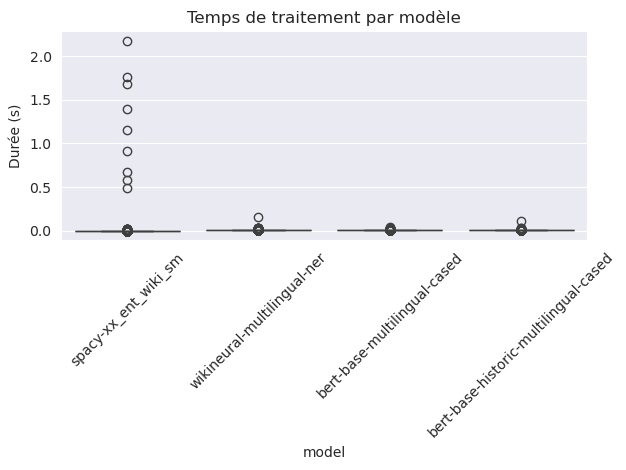

In [13]:
sns.boxplot(data=df, x="model", y="duration")
plt.xticks(rotation=45)
plt.title("Temps de traitement par modèle")
plt.ylabel("Durée (s)")
plt.tight_layout()
plt.show()

## Nombre moyen d'entités par modèle

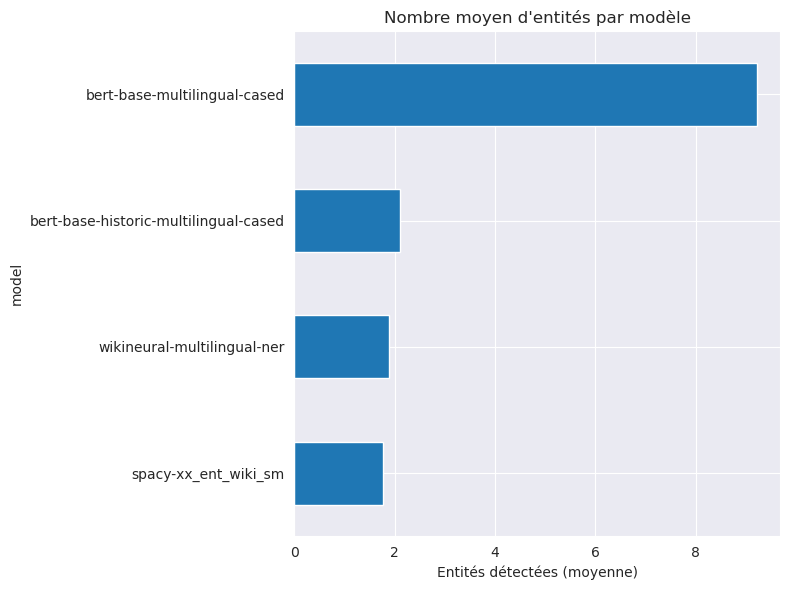

In [14]:
avg_entities = df.groupby("model")["entity_count"].mean().sort_values()

avg_entities.plot(kind="barh", title="Nombre moyen d'entités par modèle", figsize=(8, 6))
plt.xlabel("Entités détectées (moyenne)")
plt.tight_layout()
plt.show()

## Distribution de la similarité contextuelle

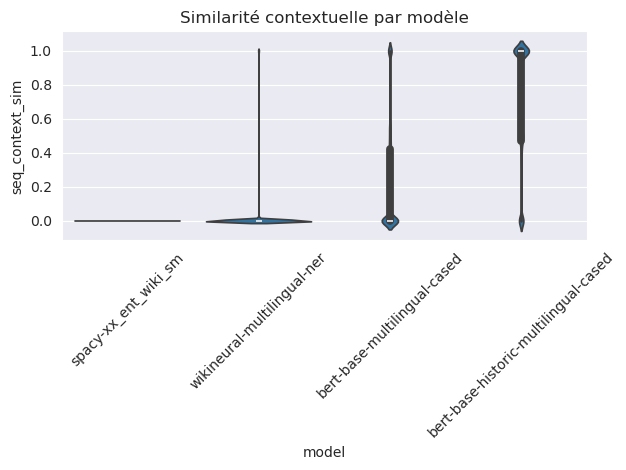

In [15]:
sns.violinplot(data=df, x="model", y="seq_context_sim")
plt.xticks(rotation=45)
plt.title("Similarité contextuelle par modèle")
plt.tight_layout()
plt.show()

## Comparaison entity_count vs tfidf_score

/tmp/ipykernel_10857/729225535.py:3: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/armotik/miniconda3/envs/codes/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


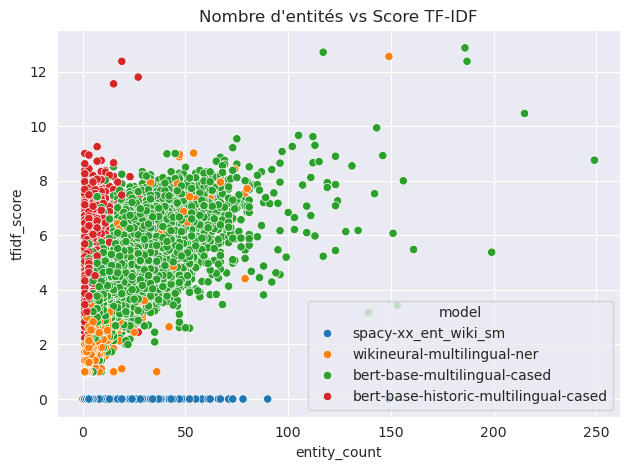

In [16]:
sns.scatterplot(data=df, x="entity_count", y="tfidf_score", hue="model")
plt.title("Nombre d'entités vs Score TF-IDF")
plt.tight_layout()
plt.show()

## Heatmap des corrélations

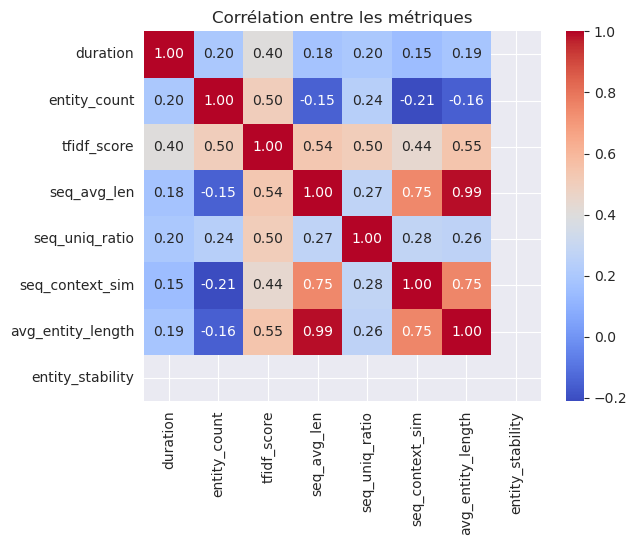

In [17]:
corr = df[[
    "duration", "entity_count", "tfidf_score", "seq_avg_len",
    "seq_uniq_ratio", "seq_context_sim", "avg_entity_length", "entity_stability"
]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Corrélation entre les métriques")
plt.show()

## Radar Chart

### wikineural

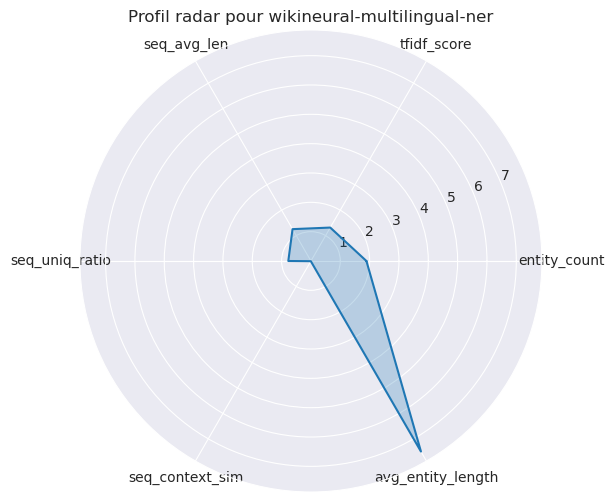

In [19]:
model_name = "wikineural-multilingual-ner"
model_data = df[df["model"] == model_name].mean(numeric_only=True)

categories = [
    "entity_count", "tfidf_score", "seq_avg_len",
    "seq_uniq_ratio", "seq_context_sim", "avg_entity_length"
]
values = model_data[categories].values.flatten().tolist()
values += values[:1]  # Pour fermer le graphe

angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
angles += angles[:1]

plt.figure(figsize=(6, 6))
ax = plt.subplot(111, polar=True)
plt.xticks(angles[:-1], categories)

ax.plot(angles, values)
ax.fill(angles, values, alpha=0.25)
plt.title(f"Profil radar pour {model_name}")
plt.show()

### spacy-xx_ent_wiki_sm

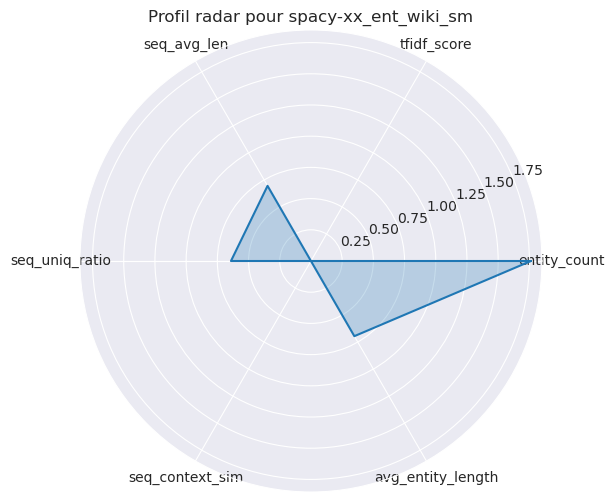

In [20]:
model_name = "spacy-xx_ent_wiki_sm"
model_data = df[df["model"] == model_name].mean(numeric_only=True)

categories = [
    "entity_count", "tfidf_score", "seq_avg_len",
    "seq_uniq_ratio", "seq_context_sim", "avg_entity_length"
]
values = model_data[categories].values.flatten().tolist()
values += values[:1]  # Pour fermer le graphe

angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
angles += angles[:1]

plt.figure(figsize=(6, 6))
ax = plt.subplot(111, polar=True)
plt.xticks(angles[:-1], categories)

ax.plot(angles, values)
ax.fill(angles, values, alpha=0.25)
plt.title(f"Profil radar pour {model_name}")
plt.show()

### bert-base-multilingual-cased

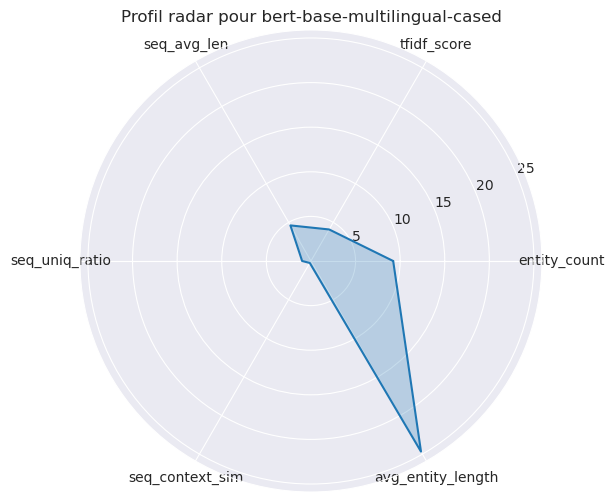

In [21]:
model_name = "bert-base-multilingual-cased"
model_data = df[df["model"] == model_name].mean(numeric_only=True)

categories = [
    "entity_count", "tfidf_score", "seq_avg_len",
    "seq_uniq_ratio", "seq_context_sim", "avg_entity_length"
]
values = model_data[categories].values.flatten().tolist()
values += values[:1]  # Pour fermer le graphe

angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
angles += angles[:1]

plt.figure(figsize=(6, 6))
ax = plt.subplot(111, polar=True)
plt.xticks(angles[:-1], categories)

ax.plot(angles, values)
ax.fill(angles, values, alpha=0.25)
plt.title(f"Profil radar pour {model_name}")
plt.show()

### bert-base-historic-multilingual-cased

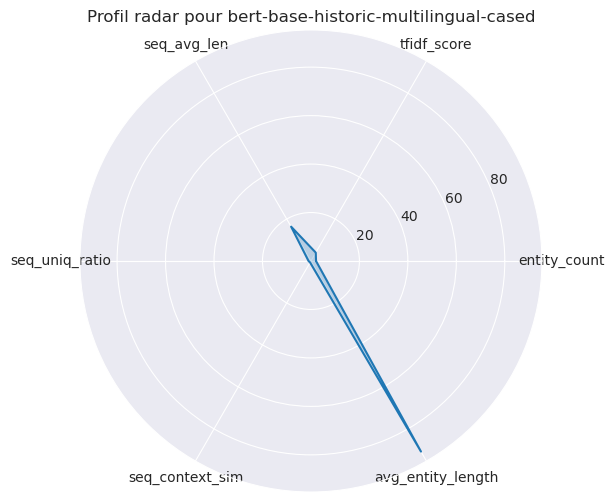

In [22]:
model_name = "bert-base-historic-multilingual-cased"
model_data = df[df["model"] == model_name].mean(numeric_only=True)

categories = [
    "entity_count", "tfidf_score", "seq_avg_len",
    "seq_uniq_ratio", "seq_context_sim", "avg_entity_length"
]
values = model_data[categories].values.flatten().tolist()
values += values[:1]  # Pour fermer le graphe

angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
angles += angles[:1]

plt.figure(figsize=(6, 6))
ax = plt.subplot(111, polar=True)
plt.xticks(angles[:-1], categories)

ax.plot(angles, values)
ax.fill(angles, values, alpha=0.25)
plt.title(f"Profil radar pour {model_name}")
plt.show()

In [25]:
from ipywidgets import interact, widgets

In [28]:
metrics = [
    "duration", "entity_count", "tfidf_score", "seq_avg_len",
    "seq_uniq_ratio", "seq_context_sim", "avg_entity_length", "entity_stability"
]

# Fonction d'affichage interactive
def show_dashboard(selected_model, selected_metric):
    df_filtered = df[df["model"] == selected_model]

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(data=df_filtered, y=selected_metric, ax=ax)
    ax.set_title(f"{selected_metric} pour {selected_model}")
    ax.set_ylabel(selected_metric)
    plt.grid(True)
    plt.show()

# Interacteurs
interact(
    show_dashboard,
    selected_model=widgets.Dropdown(options=df["model"].unique(), description="Modèle :"),
    selected_metric=widgets.Dropdown(options=metrics, description="Métrique :")
)


interactive(children=(Dropdown(description='Modèle :', options=('spacy-xx_ent_wiki_sm', 'wikineural-multilingu…

<function __main__.show_dashboard(selected_model, selected_metric)>

In [29]:
@interact
def plot_filtered_by_lang(lang=df["text_lang"].unique()):
    sns.boxplot(data=df[df["text_lang"] == lang], x="model", y="duration")
    plt.title(f"Durée de traitement pour la langue : {lang}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='lang', options=('fr', 'en'), value='fr'), Output()), _dom_classes=…

In [30]:
@interact
def compare_models(m1=df["model"].unique(), m2=df["model"].unique()):
    df1 = df[df["model"] == m1].mean(numeric_only=True)
    df2 = df[df["model"] == m2].mean(numeric_only=True)

    compare_df = pd.DataFrame({
        m1: df1,
        m2: df2
    }).dropna()

    compare_df.plot(kind="barh", figsize=(8,6), title=f"Comparaison {m1} vs {m2}")
    plt.xlabel("Valeur moyenne")
    plt.tight_layout()
    plt.show()


interactive(children=(Dropdown(description='m1', options=('spacy-xx_ent_wiki_sm', 'wikineural-multilingual-ner…

Nouvelles evaluations

##

In [40]:
df_eval = df[["text", "text_lang", "model", "duration", "entities"]]

### Ratio de mots entités / mots texte

In [41]:
import ast

df_eval["entities"] = df_eval["entities"].apply(ast.literal_eval)


/tmp/ipykernel_10857/727461439.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eval["entities"] = df_eval["entities"].apply(ast.literal_eval)


In [42]:
def ratio_entities_words(row):
    text = str(row["text"]) if pd.notna(row["text"]) else ""
    text_len = len(text.split())

    entity_words = sum(
        len(ent[0].split()) if isinstance(ent, tuple) else len(str(ent).split())
        for ent in row["entities"]
    ) if row["entities"] else 0

    return entity_words / text_len if text_len else 0


In [43]:
df_eval["entity_word_ratio"] = df_eval.apply(ratio_entities_words, axis=1)

/tmp/ipykernel_10857/4025918350.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eval["entity_word_ratio"] = df_eval.apply(ratio_entities_words, axis=1)


In [44]:
df_eval["text"] = df_eval["text"].fillna("").astype(str)

df_eval["entities"] = df_eval["entities"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

/tmp/ipykernel_10857/1160546677.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eval["text"] = df_eval["text"].fillna("").astype(str)
/tmp/ipykernel_10857/1160546677.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eval["entities"] = df_eval["entities"].apply(


### Pertinence syntaxique

In [47]:
import spacy
from tqdm import tqdm

In [39]:
nlp_fr = spacy.load("fr_core_news_sm")
nlp_en = spacy.load("en_core_web_sm")

In [48]:
def batch_named_pos(df, lang_model):
    results = []
    texts = df["text"].tolist()
    entities = df["entities"].tolist()

    for doc, ents in tqdm(zip(lang_model.pipe(texts, batch_size=64), entities), total=len(texts)):
        named_tokens = {tok.text for tok in doc if tok.pos_ in ["PROPN", "NOUN"]}
        match_count = sum(1 for ent in ents if isinstance(ent, tuple) and ent[0] in named_tokens)
        ratio = match_count / len(ents) if ents else 0
        results.append(ratio)
    return results

In [49]:
df_fr = df_eval[df_eval["text_lang"] == "fr"]
df_en = df_eval[df_eval["text_lang"] == "en"]
df_eval.loc[df_fr.index, "named_pos_ratio"] = batch_named_pos(df_fr, nlp_fr)
df_eval.loc[df_en.index, "named_pos_ratio"] = batch_named_pos(df_en, nlp_en)

100%|██████████| 607008/607008 [27:00<00:00, 374.57it/s]
/tmp/ipykernel_10857/4198869125.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eval.loc[df_fr.index, "named_pos_ratio"] = batch_named_pos(df_fr, nlp_fr)
100%|██████████| 794660/794660 [32:30<00:00, 407.32it/s]


### Redondance / répétition des entités

In [50]:
def entity_uniqueness_ratio(row):
    all_texts = [ent[0] if isinstance(ent, tuple) else ent for ent in row["entities"]]
    return len(set(all_texts)) / len(all_texts) if all_texts else 1

df_eval["entity_uniqueness"] = df_eval.apply(entity_uniqueness_ratio, axis=1)

/tmp/ipykernel_10857/715904247.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eval["entity_uniqueness"] = df_eval.apply(entity_uniqueness_ratio, axis=1)


### Longueur moyenne des entités

In [51]:
def avg_entity_len(row):
    ent_lengths = [len(ent[0]) if isinstance(ent, tuple) else len(ent) for ent in row["entities"]]
    return sum(ent_lengths) / len(ent_lengths) if ent_lengths else 0

df_eval["avg_entity_length"] = df_eval.apply(avg_entity_len, axis=1)

/tmp/ipykernel_10857/373742303.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eval["avg_entity_length"] = df_eval.apply(avg_entity_len, axis=1)


In [52]:
df_eval

,text,text_lang,model,duration,entities,entity_word_ratio,named_pos_ratio,entity_uniqueness,avg_entity_length
0,"Paul Jules Antoine Meillet, né le à Moulins (A...",fr,spacy-xx_ent_wiki_sm,1.684165,"[Paul Jules Antoine Meillet, Moulins, Allier, ...",0.333333,0.000000,1.000000,11.600000
1,"Paul Jules Antoine Meillet, né le à Moulins (A...",fr,wikineural-multilingual-ner,0.154518,"[(Paul Jules Antoine Meillet, PER), (Moulins, ...",0.333333,0.600000,1.000000,11.600000
2,"Paul Jules Antoine Meillet, né le à Moulins (A...",fr,bert-base-multilingual-cased,0.013205,"[(Paul, LABEL_0), (Jules Antoine Meillet, né, ...",1.208333,0.250000,1.000000,12.333333
3,"Paul Jules Antoine Meillet, né le à Moulins (A...",fr,bert-base-historic-multilingual-cased,0.009076,"[(Paul Jules Antoine Meillet, né le à Moulins ...",1.208333,0.000000,1.000000,51.666667
4,Il est aussi philologue.,fr,spacy-xx_ent_wiki_sm,0.002208,[],0.000000,0.000000,1.000000,0.000000
...,...,...,...,...,...,...,...,...,...
1401663,Debian developers contributed discussion and c...,en,bert-base-historic-multilingual-cased,0.007384,[(Debian developers contributed discussion and...,1.000000,0.000000,1.000000,170.000000
1401664,Part of the Debian Social Contract was the Deb...,en,spacy-xx_ent_wiki_sm,0.003597,"[Debian Social Contract, Debian Free Software ...",0.205128,0.000000,1.000000,19.666667
1401665,Part of the Debian Social Contract was the Deb...,en,wikineural-multilingual-ner,0.008035,"[(Debian Social Contract, MISC), (Debian Free ...",0.205128,0.333333,1.000000,19.666667
1401666,Part of the Debian Social Contract was the Deb...,en,bert-base-multilingual-cased,0.008142,[(Part of the Debian Social Contract was the D...,1.076923,0.000000,0.923077,16.846154


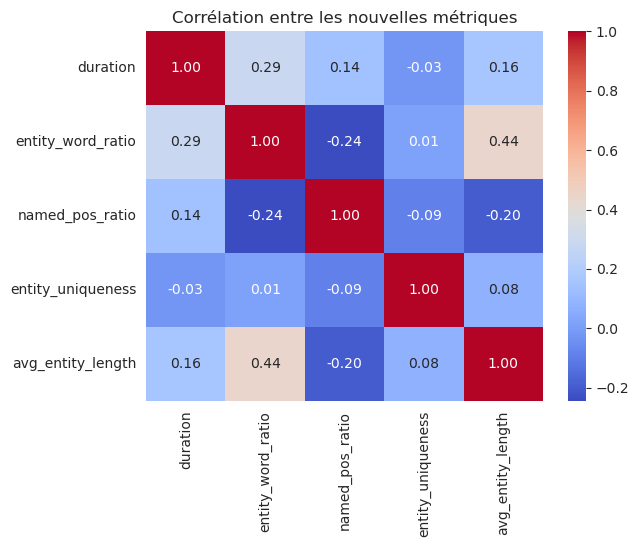

In [55]:
corr = df_eval[[
    "duration", "entity_word_ratio", "named_pos_ratio", "entity_uniqueness", "avg_entity_length",
]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Corrélation entre les nouvelles métriques")
plt.show()

In [56]:
@interact
def compare_models(m1=df["model"].unique(), m2=df_eval["model"].unique()):
    df1 = df_eval[df_eval["model"] == m1].mean(numeric_only=True)
    df2 = df_eval[df_eval["model"] == m2].mean(numeric_only=True)

    compare_df = pd.DataFrame({
        m1: df1,
        m2: df2
    }).dropna()

    compare_df.plot(kind="barh", figsize=(8,6), title=f"Comparaison {m1} vs {m2}")
    plt.xlabel("Valeur moyenne")
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='m1', options=('spacy-xx_ent_wiki_sm', 'wikineural-multilingual-ner…

In [57]:
df_wikineural = df_eval[df_eval["model"] == "wikineural-multilingual-ner"]

In [59]:
df_wikineural

,text,text_lang,model,duration,entities,entity_word_ratio,named_pos_ratio,entity_uniqueness,avg_entity_length
1,"Paul Jules Antoine Meillet, né le à Moulins (A...",fr,wikineural-multilingual-ner,0.154518,"[(Paul Jules Antoine Meillet, PER), (Moulins, ...",0.333333,0.600000,1.000000,11.600000
5,Il est aussi philologue.,fr,wikineural-multilingual-ner,0.009519,"[(phi, MISC), (##lo, MISC)]",0.500000,0.000000,1.000000,3.500000
9,"D'origine bourbonnaise, fils d'un notaire de C...",fr,wikineural-multilingual-ner,0.008091,"[(Châteaumeillant, LOC), (Cher, LOC), (Antoine...",0.277778,0.500000,1.000000,10.250000
13,Étudiant à la faculté des lettres de Paris à p...,fr,wikineural-multilingual-ner,0.008412,"[(Paris, LOC), (Louis Havet, PER), (Michel Bré...",0.363636,0.166667,1.000000,16.333333
17,"En 1889, il est major de l'agrégation de gramm...",fr,wikineural-multilingual-ner,0.007283,"[(grammaire, MISC)]",0.111111,1.000000,1.000000,9.000000
...,...,...,...,...,...,...,...,...,...
1401649,Perens took this as inspiration to create a fo...,en,wikineural-multilingual-ner,0.006940,"[(Perens, PER), (Debian, MISC)]",0.153846,1.000000,1.000000,6.000000
1401653,"In a blog posting, Perens claims not to have m...",en,wikineural-multilingual-ner,0.007749,"[(Perens, PER), (Three Freedoms, MISC), (Four ...",0.275862,0.250000,1.000000,14.250000
1401657,Perens proposed a draft of the Debian Social C...,en,wikineural-multilingual-ner,0.007692,"[(Perens, PER), (Debian Social Contract, MISC)...",0.227273,0.666667,1.000000,11.333333
1401661,Debian developers contributed discussion and c...,en,wikineural-multilingual-ner,0.007699,"[(Debian, MISC), (Perens, PER), (Debian, MISC)]",0.115385,0.333333,0.666667,6.000000


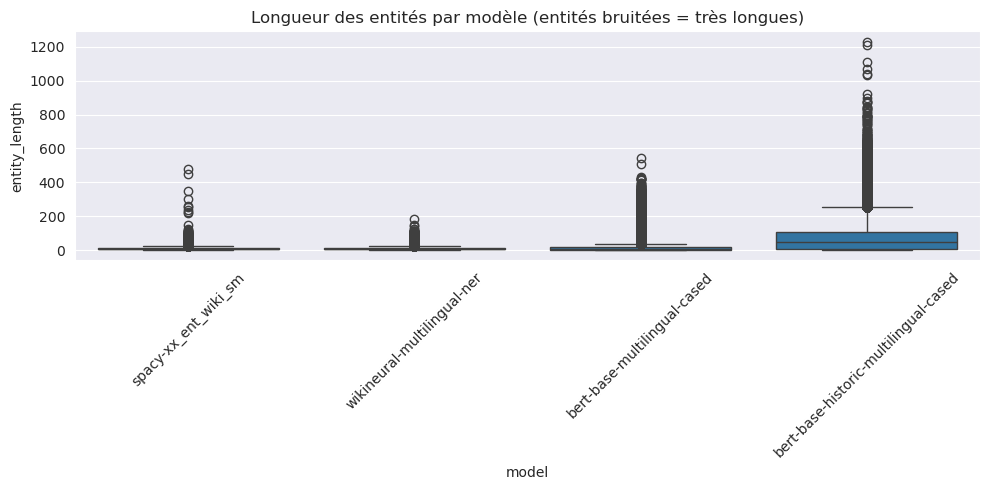

In [60]:
df_expanded = df_eval.explode("entities")
df_expanded["entity_length"] = df_expanded["entities"].apply(
    lambda e: len(e[0]) if isinstance(e, tuple) else len(str(e))
)

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_expanded, x="model", y="entity_length")
plt.title("Longueur des entités par modèle (entités bruitées = très longues)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

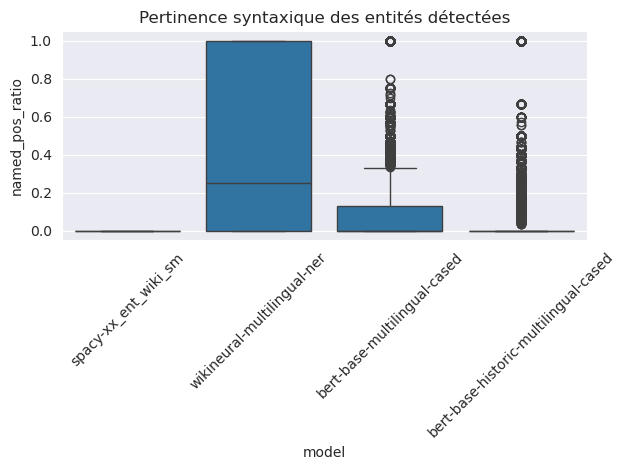

In [61]:
sns.boxplot(data=df_eval, x="model", y="named_pos_ratio")
plt.title("Pertinence syntaxique des entités détectées")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

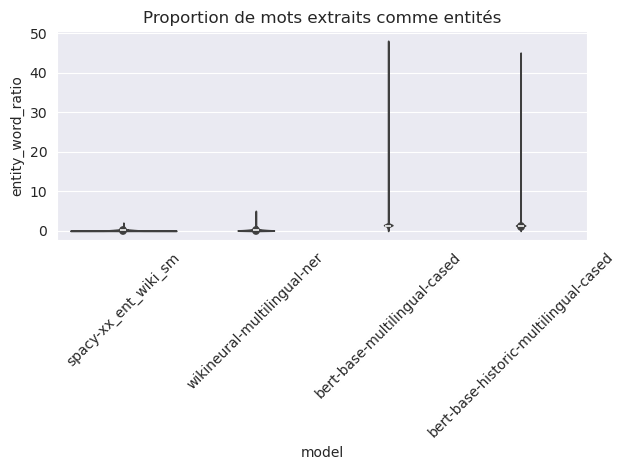

In [63]:
sns.violinplot(data=df_eval, x="model", y="entity_word_ratio")
plt.title("Proportion de mots extraits comme entités")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [62]:
test_df = pd.read_csv("../../tests/test.csv")

In [59]:
len(test_df)

834

In [20]:
import ast

In [63]:
all_entities = []

for i, row in test_df.iterrows():

    entities = ast.literal_eval(row["meta"])
    all_entities.extend(entities["entities"])

In [64]:
tests = []

for ent, ent_type in all_entities:
    if len(ent) <= 3:
        tests.append((ent, ent_type))

print(tests)

[('Mei', 'PER'), ('Mei', 'PER'), ('Las', 'LOC'), ('UCR', 'ORG'), ('Int', 'ORG'), ('IRA', 'ORG'), ('Ost', 'LOC'), ('Est', 'LOC'), ('Inn', 'LOC'), ('LPF', 'ORG'), ('LPF', 'ORG'), ('CNT', 'ORG'), ('CNT', 'ORG'), ('CNT', 'ORG'), ('IWW', 'ORG'), ('CNT', 'ORG'), ('CNT', 'ORG'), ('CNT', 'ORG'), ('SWF', 'ORG'), ('AFB', 'ORG'), ('AFB', 'ORG'), ('SWF', 'ORG'), ('WTO', 'ORG'), ('WEF', 'ORG'), ('WTO', 'ORG'), ('CGT', 'ORG'), ('CNT', 'ORG'), ('CGT', 'ORG'), ('PKK', 'ORG'), ('CNT', 'ORG'), ('Ana', 'ORG'), ('Ana', 'ORG'), ('God', 'PER'), ('God', 'PER')]
